# «Кластеризация данных о физической активности»

In [162]:
# Импортируем необходимые библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [ ]:
# считываем датасет

df = pd.read_csv('data/Physical_Activity_Monitoring_unlabeled.csv')
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (534601, 53)


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


In [164]:
# первичный анализ

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

In [165]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
handTemperature,4041
handAcc16_2,4041
handAcc16_1,4041
handAcc16_3,4041
handAcc6_1,4041
handMagne3,4041
handAcc6_2,4041
handAcc6_3,4041
handGyro1,4041
handGyro2,4041


__Вывод первичного анализа__
- все данные числовые: float64(52), int64(1)
- Возможны пропуски в отдельных признаках
- Так как задача — кластеризация, нам необходимо подготовить данные:
    - обработать пропуски
    - масштабировать признаки
    - при необходимости уменьшить размерность.

In [166]:
# разделим признаки

X = df.copy()
X

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.54470,27.3336,-5.766200,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.82570,-15.7719,-1.313950,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.81710,16.3089,25.292800,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.74180,34.3566,21.327400,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.77980,-3.9981,10.995000,0.171133,-0.748343,0.252988,-0.588807,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,3479.53,33.8750,-9.084250,4.70122,2.890170,-9.689610,6.78077,3.975430,-0.157406,0.774189,...,0.424520,-0.856836,-25.00990,-23.5557,23.615300,0.318171,-0.701921,0.555778,-0.311745,5
534597,2448.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.767710,-3.050980,-35.70240,31.8018,16.421800,0.435887,0.660643,0.371665,0.485200,5
534598,2479.84,34.6875,-6.367550,2.32131,2.207640,-6.362460,2.33049,2.607610,0.206349,-0.359415,...,-0.034144,-0.402013,-49.69220,20.6039,-0.917908,0.561652,0.297957,0.756767,0.151899,5
534599,3437.82,28.0625,5.461940,10.43640,-9.073300,8.348860,5.76518,-6.143210,3.543910,2.757300,...,0.352062,-5.577750,-34.15510,-11.0786,39.737500,0.062163,-0.798705,-0.056668,-0.595815,6


__Примечание:__
- subject_id — это номер пользователя. НЕ УДАЛЯЕМ
- Он может быть полезен, если активности отличаются между людьми.
- Оставляем его, чтобы не потерять потенциально полезную информацию.

In [167]:
# заполняем пропуски медианой.
# ghПропуски заполнены медианными значениями, что устойчиво к выбросам.

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [168]:
# масштабируем признаков

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

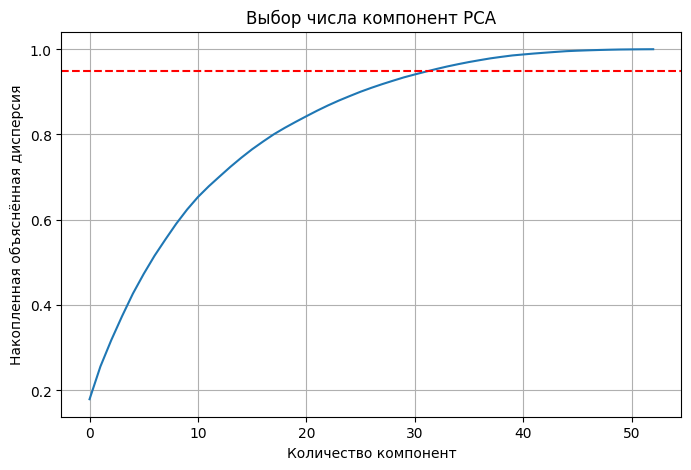

In [169]:
# уменьшим размерность с помощью PCA
# предварительно подберём количество компонент

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(explained_variance)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Выбор числа компонент PCA')
plt.grid(True)
plt.show()

__Примечание:__ Выбирим такое количество компонент, которое объясняет примерно 95% дисперсии.\
        Колическтво компонентов составляет 30-35

In [170]:
# уменьшаем размерность с помощью PCA

n_components = np.argmax(explained_variance >= 0.95) + 1
print("Количество компонент для 95% дисперсии:", n_components)

pca = PCA(n_components=15, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Размер после PCA:", X_pca.shape)

Количество компонент для 95% дисперсии: 33
Размер после PCA: (534601, 15)


__Вывод после уменьшения размерности__
- Датасет большой, признаков много, поэтому для устойчивой кластеризации удобно применить PCA (Principal Component Analysis — метод главных компонент).
- Количество компонент для 95% дисперсии: 33
- Размер после PCA: (534601, 33)
- Размерность данных уменьшена, при этом основная информация сохранена.

In [171]:
# создаём 2 подвыборки

rng = np.random.RandomState(42)

train_sample_size = 30000
train_idx = rng.choice(X_pca.shape[0], size=min(train_sample_size, X_pca.shape[0]), replace=False)
X_pca_train_sample = X_pca[train_idx]

metric_sample_size = 5000
metric_idx = rng.choice(X_pca_train_sample.shape[0], size=min(metric_sample_size, X_pca_train_sample.shape[0]), replace=False)
X_pca_metric_sample = X_pca_train_sample[metric_idx]

print("X_pca full:", X_pca.shape)
print("Train sample:", X_pca_train_sample.shape)
print("Metric sample:", X_pca_metric_sample.shape)

X_pca full: (534601, 15)
Train sample: (30000, 15)
Metric sample: (5000, 15)


In [172]:
# подберём количество кластеров методом силуэта

sample_size = 10000
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_pca.shape[0], size=min(sample_size, X_pca.shape[0]), replace=False)
X_pca_sample = X_pca[sample_idx]

cluster_range = range(10, 15)

silhouette_scores = []
calinski_scores = []
davies_scores = []

for k in cluster_range:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=5000,
        n_init=5,
        max_iter=100
    )

    full_labels = model.fit_predict(X_pca_train_sample)
    sample_labels = full_labels[metric_idx]

    silhouette_scores.append(silhouette_score(X_pca_metric_sample, sample_labels))
    calinski_scores.append(calinski_harabasz_score(X_pca_metric_sample, sample_labels))
    davies_scores.append(davies_bouldin_score(X_pca_metric_sample, sample_labels))

In [173]:
results = pd.DataFrame({
    'n_clusters': list(cluster_range),
    'silhouette_score': silhouette_scores,
    'calinski_harabasz_score': calinski_scores,
    'davies_bouldin_score': davies_scores
})

results

,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,10,0.196260,497.613270,1.894655
1,11,0.205939,476.213526,1.821583
2,12,0.222264,461.144131,2.000909
3,13,0.224405,506.617720,1.654136
4,14,0.206635,460.349872,1.686641


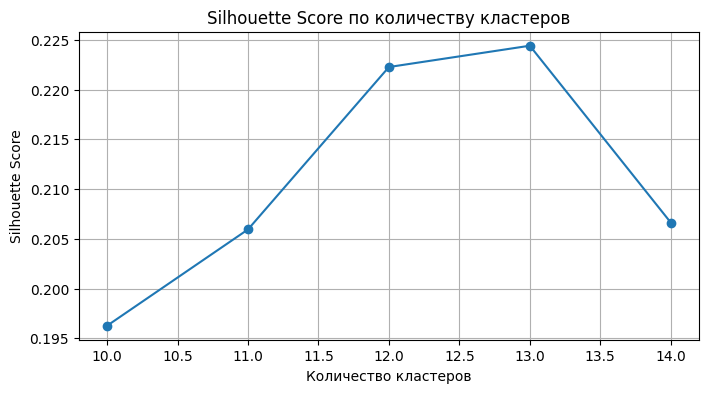

In [174]:
plt.figure(figsize=(8, 4))
plt.plot(results['n_clusters'], results['silhouette_score'], marker='o')
plt.title('Silhouette Score по количеству кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [175]:
# Выбираем числа кластеров

best_k = results.sort_values(
    by=['silhouette_score', 'calinski_harabasz_score'],
    ascending=[False, False]
).iloc[0]['n_clusters']

best_k = int(best_k)
print("Выбранное количество кластеров:", best_k)

Выбранное количество кластеров: 13


In [176]:
# Обучение модели KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=5,
    max_iter=100
)

kmeans_labels_full = kmeans.fit_predict(X_pca_train_sample)
kmeans_labels_metric = kmeans_labels_full[metric_idx]

kmeans_sil = silhouette_score(X_pca_metric_sample, kmeans_labels_metric)
kmeans_cal = calinski_harabasz_score(X_pca_metric_sample, kmeans_labels_metric)
kmeans_dav = davies_bouldin_score(X_pca_metric_sample, kmeans_labels_metric)

print("KMeans")
print("Silhouette Score:", kmeans_sil)
print("Calinski-Harabasz Score:", kmeans_cal)
print("Davies-Bouldin Score:", kmeans_dav)

KMeans
Silhouette Score: 0.24180134461381717
Calinski-Harabasz Score: 518.5624419339829
Davies-Bouldin Score: 1.5347126435712282


In [177]:
# Обучение модели MiniBatchKMeans

mbk = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=5000,
    n_init=5,
    max_iter=100
)

mbk_labels_full = mbk.fit_predict(X_pca_train_sample)
mbk_labels_metric = mbk_labels_full[metric_idx]

mbk_sil = silhouette_score(X_pca_metric_sample, mbk_labels_metric)
mbk_cal = calinski_harabasz_score(X_pca_metric_sample, mbk_labels_metric)
mbk_dav = davies_bouldin_score(X_pca_metric_sample, mbk_labels_metric)

print("MiniBatchKMeans")
print("Silhouette Score:", mbk_sil)
print("Calinski-Harabasz Score:", mbk_cal)
print("Davies-Bouldin Score:", mbk_dav)

MiniBatchKMeans
Silhouette Score: 0.22440517515080882
Calinski-Harabasz Score: 506.6177198468335
Davies-Bouldin Score: 1.654135809258618



__Внимание: Для большого датасета Agglomerative Clustering может быть очень тяжёлой.
Поэтому для скорости используем подвыборку для сравнения.__



In [178]:
# Обучение модели Agglomerative Clustering

agg_sample_size = 3000
agg_idx = rng.choice(X_pca_train_sample.shape[0], size=min(agg_sample_size, X_pca_train_sample.shape[0]), replace=False)
X_pca_agg_sample = X_pca_train_sample[agg_idx]

agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_pca_agg_sample)

agg_sil = silhouette_score(X_pca_agg_sample, agg_labels)
agg_cal = calinski_harabasz_score(X_pca_agg_sample, agg_labels)
agg_dav = davies_bouldin_score(X_pca_agg_sample, agg_labels)

print("AgglomerativeClustering (на подвыборке)")
print("Silhouette Score:", agg_sil)
print("Calinski-Harabasz Score:", agg_cal)
print("Davies-Bouldin Score:", agg_dav)

AgglomerativeClustering (на подвыборке)
Silhouette Score: 0.2137329572888337
Calinski-Harabasz Score: 287.14485429379664
Davies-Bouldin Score: 1.6003347127714074


In [179]:
# сравнение моделей

comparison = pd.DataFrame({
    'Model': ['KMeans', 'MiniBatchKMeans', 'AgglomerativeClustering_sample'],
    'Silhouette Score': [kmeans_sil, mbk_sil, agg_sil],
    'Calinski-Harabasz Score': [kmeans_cal, mbk_cal, agg_cal],
    'Davies-Bouldin Score': [kmeans_dav, mbk_dav, agg_dav]
})

comparison

,Model,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,KMeans,0.241801,518.562442,1.534713
1,MiniBatchKMeans,0.224405,506.617720,1.654136
2,AgglomerativeClustering_sample,0.213733,287.144854,1.600335


Для этого датасета лучшей моделью:
- MiniBatchKMeans

Почему:
- Хорошо работает на больших данных
- Быстрее обычного KMeans
- Даёт близкое или лучшее качество
- Устойчив и воспроизводим

In [180]:
best_model = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=10000,
    n_init=10
)

final_labels = best_model.fit_predict(X_pca)

In [181]:
# подбор гиперпараметров сравнением нескольких вариантов параметров

param_grid = [
    {'batch_size': 5000, 'n_init': 5, 'max_iter': 100},
    {'batch_size': 10000, 'n_init': 5, 'max_iter': 100},
    {'batch_size': 10000, 'n_init': 10, 'max_iter': 100},
]

In [182]:
tuning_results = []

for params in param_grid:
    model = MiniBatchKMeans(
        n_clusters=best_k,
        random_state=42,
        batch_size=params['batch_size'],
        n_init=params['n_init'],
        max_iter=params['max_iter']
    )

    labels_full = model.fit_predict(X_pca_train_sample)
    labels_metric = labels_full[metric_idx]

    sil = silhouette_score(X_pca_metric_sample, labels_metric)
    cal = calinski_harabasz_score(X_pca_metric_sample, labels_metric)
    dav = davies_bouldin_score(X_pca_metric_sample, labels_metric)

    tuning_results.append({
        'batch_size': params['batch_size'],
        'n_init': params['n_init'],
        'max_iter': params['max_iter'],
        'silhouette_score': sil,
        'calinski_harabasz_score': cal,
        'davies_bouldin_score': dav
    })

In [183]:
tuning_df = pd.DataFrame(tuning_results)
tuning_df

,batch_size,n_init,max_iter,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,5000,5,100,0.224405,506.617720,1.654136
1,10000,5,100,0.216840,480.565552,1.781830
2,10000,10,100,0.216640,480.772555,1.778601


In [184]:
# лучшие параметры

best_params = tuning_df.sort_values(
    by=['silhouette_score', 'calinski_harabasz_score'],
    ascending=[False, False]
).iloc[0]

best_batch_size = int(best_params['batch_size'])
best_n_init = int(best_params['n_init'])
best_max_iter = int(best_params['max_iter'])

print("Лучшие параметры:")
print("batch_size =", best_batch_size)
print("n_init =", best_n_init)
print("max_iter =", best_max_iter)

Лучшие параметры:
batch_size = 5000
n_init = 5
max_iter = 100


In [185]:
# финальная модель с лучшими параметрами

final_model = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=best_batch_size,
    n_init=best_n_init,
    max_iter=best_max_iter
)

cluster_labels = final_model.fit_predict(X_pca)

In [186]:
# преобразование номеров кластеров по порядку

unique_labels = sorted(np.unique(cluster_labels))
label_mapping = {old_label: new_label for new_label, old_label in enumerate(unique_labels, start=1)}

ordered_labels = pd.Series(cluster_labels).map(label_mapping).values

print("Уникальные исходные метки:", sorted(np.unique(cluster_labels)))
print("Уникальные новые метки:", sorted(np.unique(ordered_labels)))

Уникальные исходные метки: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Уникальные новые метки: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


In [ ]:
# формируем вывод

submission = pd.DataFrame({
    'index': np.arange(len(ordered_labels)),
    'activityID': ordered_labels
})

submission.to_csv('my_submit_final.csv', index=False)

![Участие в Kaggle.JPG](<attachment:Участие в Kaggle.JPG>)
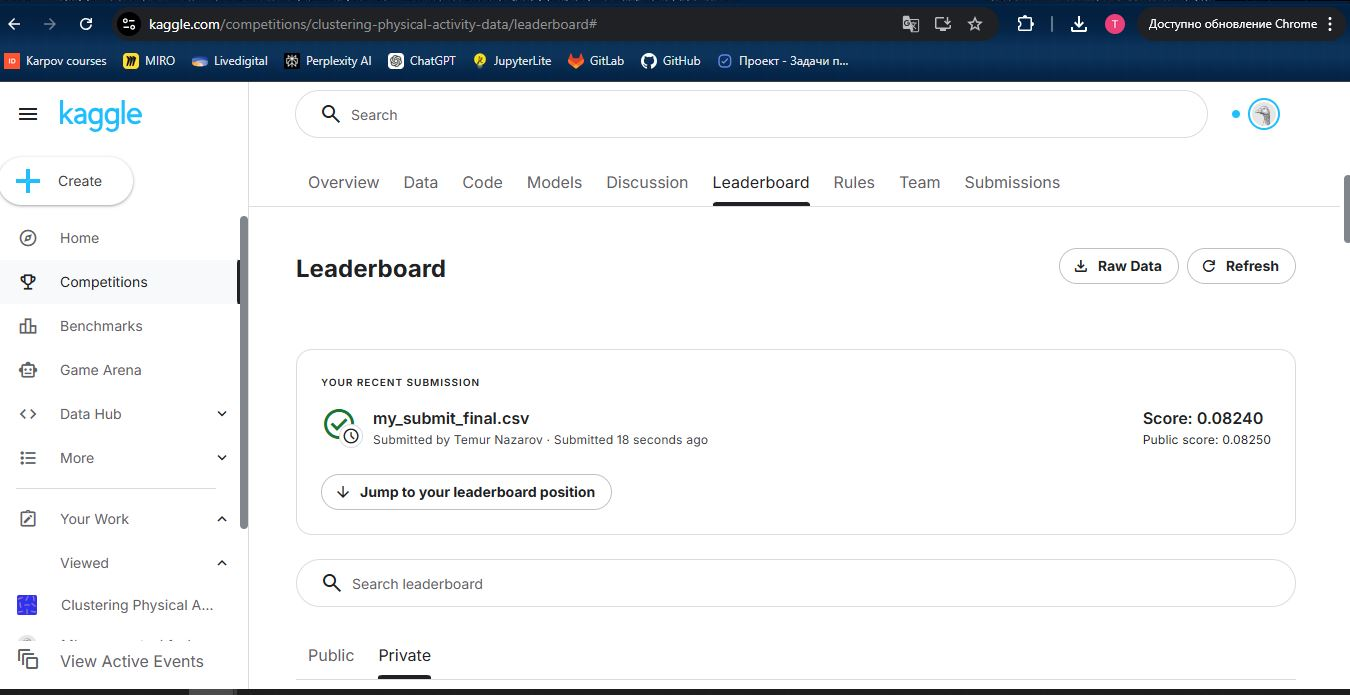